# Importing required modules/libraries


In [346]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib

import warnings
warnings.filterwarnings('ignore')

# EDA

In [347]:
df = pd.read_csv('loan_detection.csv')
df

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


In [348]:
df.shape


(41188, 60)

## Data Cleaning

### Handling null or duplicate data

In [349]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age                            41188 non-null  int64
 1   campaign                       41188 non-null  int64
 2   pdays                          41188 non-null  int64
 3   previous                       41188 non-null  int64
 4   no_previous_contact            41188 non-null  int64
 5   not_working                    41188 non-null  int64
 6   job_admin.                     41188 non-null  int64
 7   job_blue-collar                41188 non-null  int64
 8   job_entrepreneur               41188 non-null  int64
 9   job_housemaid                  41188 non-null  int64
 10  job_management                 41188 non-null  int64
 11  job_retired                    41188 non-null  int64
 12  job_self-employed              41188 non-null  int64
 13  job_services    

In [350]:
df.duplicated().sum()

np.int64(2417)

In [351]:
df[df.duplicated()]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
10,41,1,999,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
11,25,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
16,35,1,999,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
31,59,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
104,52,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40928,21,1,999,0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
41131,58,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
41167,32,3,999,0,1,0,1,0,0,0,...,0,0,0,0,0,1,0,1,0,0
41172,31,1,999,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,1


In [352]:
df.drop_duplicates(keep = 'first', inplace = True)

In [353]:
df.shape

(38771, 60)

### Handling outliers

In [354]:
df.describe()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
count,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,...,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000,38771.000000
mean,40.171107,2.635630,960.224188,0.181373,0.960950,0.090686,0.248510,0.223595,0.036187,0.026360,...,0.014547,0.191638,0.209125,0.207784,0.195249,0.196203,0.107374,0.857239,0.035387,0.118439
std,10.492319,2.832271,192.358267,0.506562,0.193716,0.287166,0.432155,0.416659,0.186757,0.160205,...,0.119732,0.393595,0.406689,0.405727,0.396397,0.397129,0.309592,0.349834,0.184759,0.323131
min,17.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,1.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,38.000000,2.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,47.000000,3.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,98.000000,56.000000,999.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [355]:
int_cols = [c for c in df.columns if df[c].nunique() > 2]
int_cols

['age', 'campaign', 'pdays', 'previous']

		age



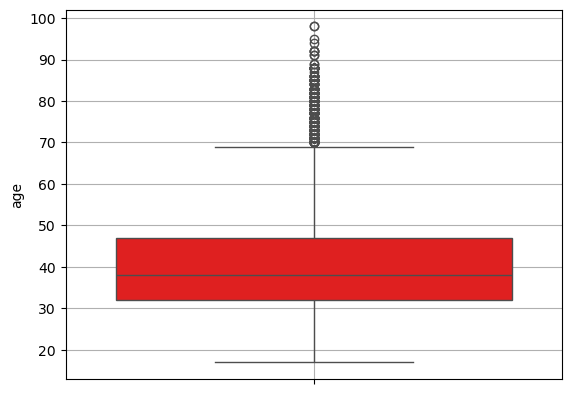

		campaign



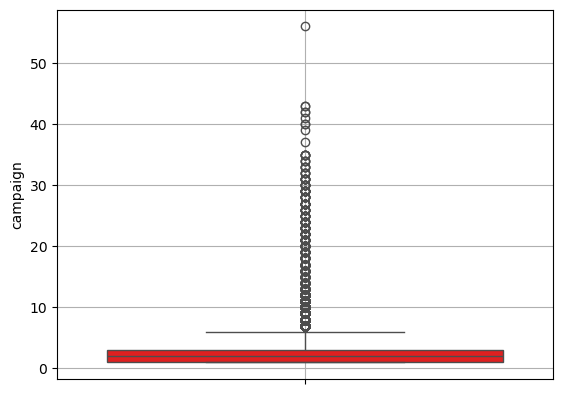

		pdays



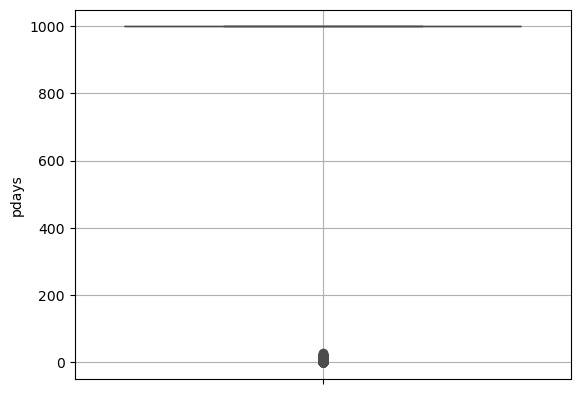

		previous



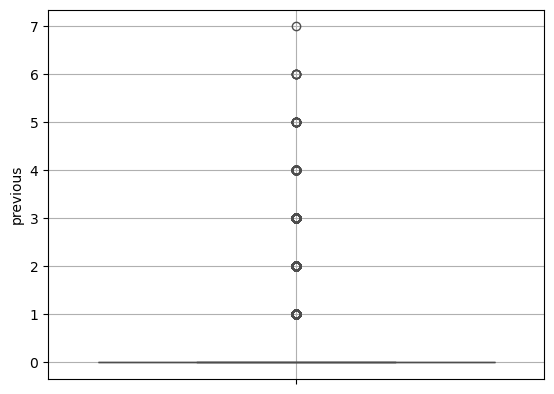

In [356]:
int_cols = [c for c in df.columns if df[c].nunique() > 2]
for i in int_cols:
    if i == 'Loan_Status_Label':
        pass
    else:
        print(f'\t\t{i}\n')
        sns.boxplot(df[i], color = 'r')
        plt.grid()
        plt.show()

In [357]:
df['pdays'].value_counts()

pdays
999    37257
3        438
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [358]:
df.drop(columns = ['pdays', 'campaign', 'previous'], inplace = True)
df.shape

(38771, 57)

#### Using IQR to remove outliers

In [359]:
# IQR

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
print(f'{IQR}')

15.0


In [360]:
# Defining upper and lower bound

lb = Q1 - 1.5*IQR
ub = Q3 + 1.5*IQR
print(f'Lower bound:\t{lb}\t\tUpper bound:\t{ub}')

Lower bound:	9.5		Upper bound:	69.5


In [361]:
df = df[~((df['age'] < lb) | (df['age'] > ub))]

In [362]:
df.shape

(38314, 57)

In [363]:
df.describe()

,age,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
count,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,...,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000,38314.000000
mean,39.732891,0.963042,0.081119,0.251266,0.226184,0.036618,0.026022,0.072845,0.033147,0.035992,...,0.013259,0.191653,0.209349,0.207705,0.194811,0.196482,0.105784,0.860782,0.033434,0.114188
std,9.732368,0.188661,0.273022,0.433747,0.418365,0.187826,0.159202,0.259886,0.179023,0.186273,...,0.114383,0.393607,0.406849,0.405670,0.396061,0.397342,0.307565,0.346178,0.179770,0.318044
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,38.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,47.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Checking for imbalance in data

In [364]:
df.duplicated().sum()

np.int64(3598)

In [365]:
df.drop_duplicates(keep = 'first', inplace = True)

In [366]:
df.shape

(34716, 57)

In [367]:
df['Loan_Status_label'].value_counts()

Loan_Status_label
0    30430
1     4286
Name: count, dtype: int64

In [368]:
print(round(len(df[df['Loan_Status_label'] == 0])/len(df) * 100, 2))
print(round(len(df[df['Loan_Status_label'] == 1])/len(df) * 100, 2))

87.65
12.35


In [369]:
y = df['Loan_Status_label']
df_major = df[y == 0]
df_minor = df[y == 1]

# Combine
sample = pd.concat([df_major, df_minor])

sample.shape

(34716, 57)

## Feature Selection

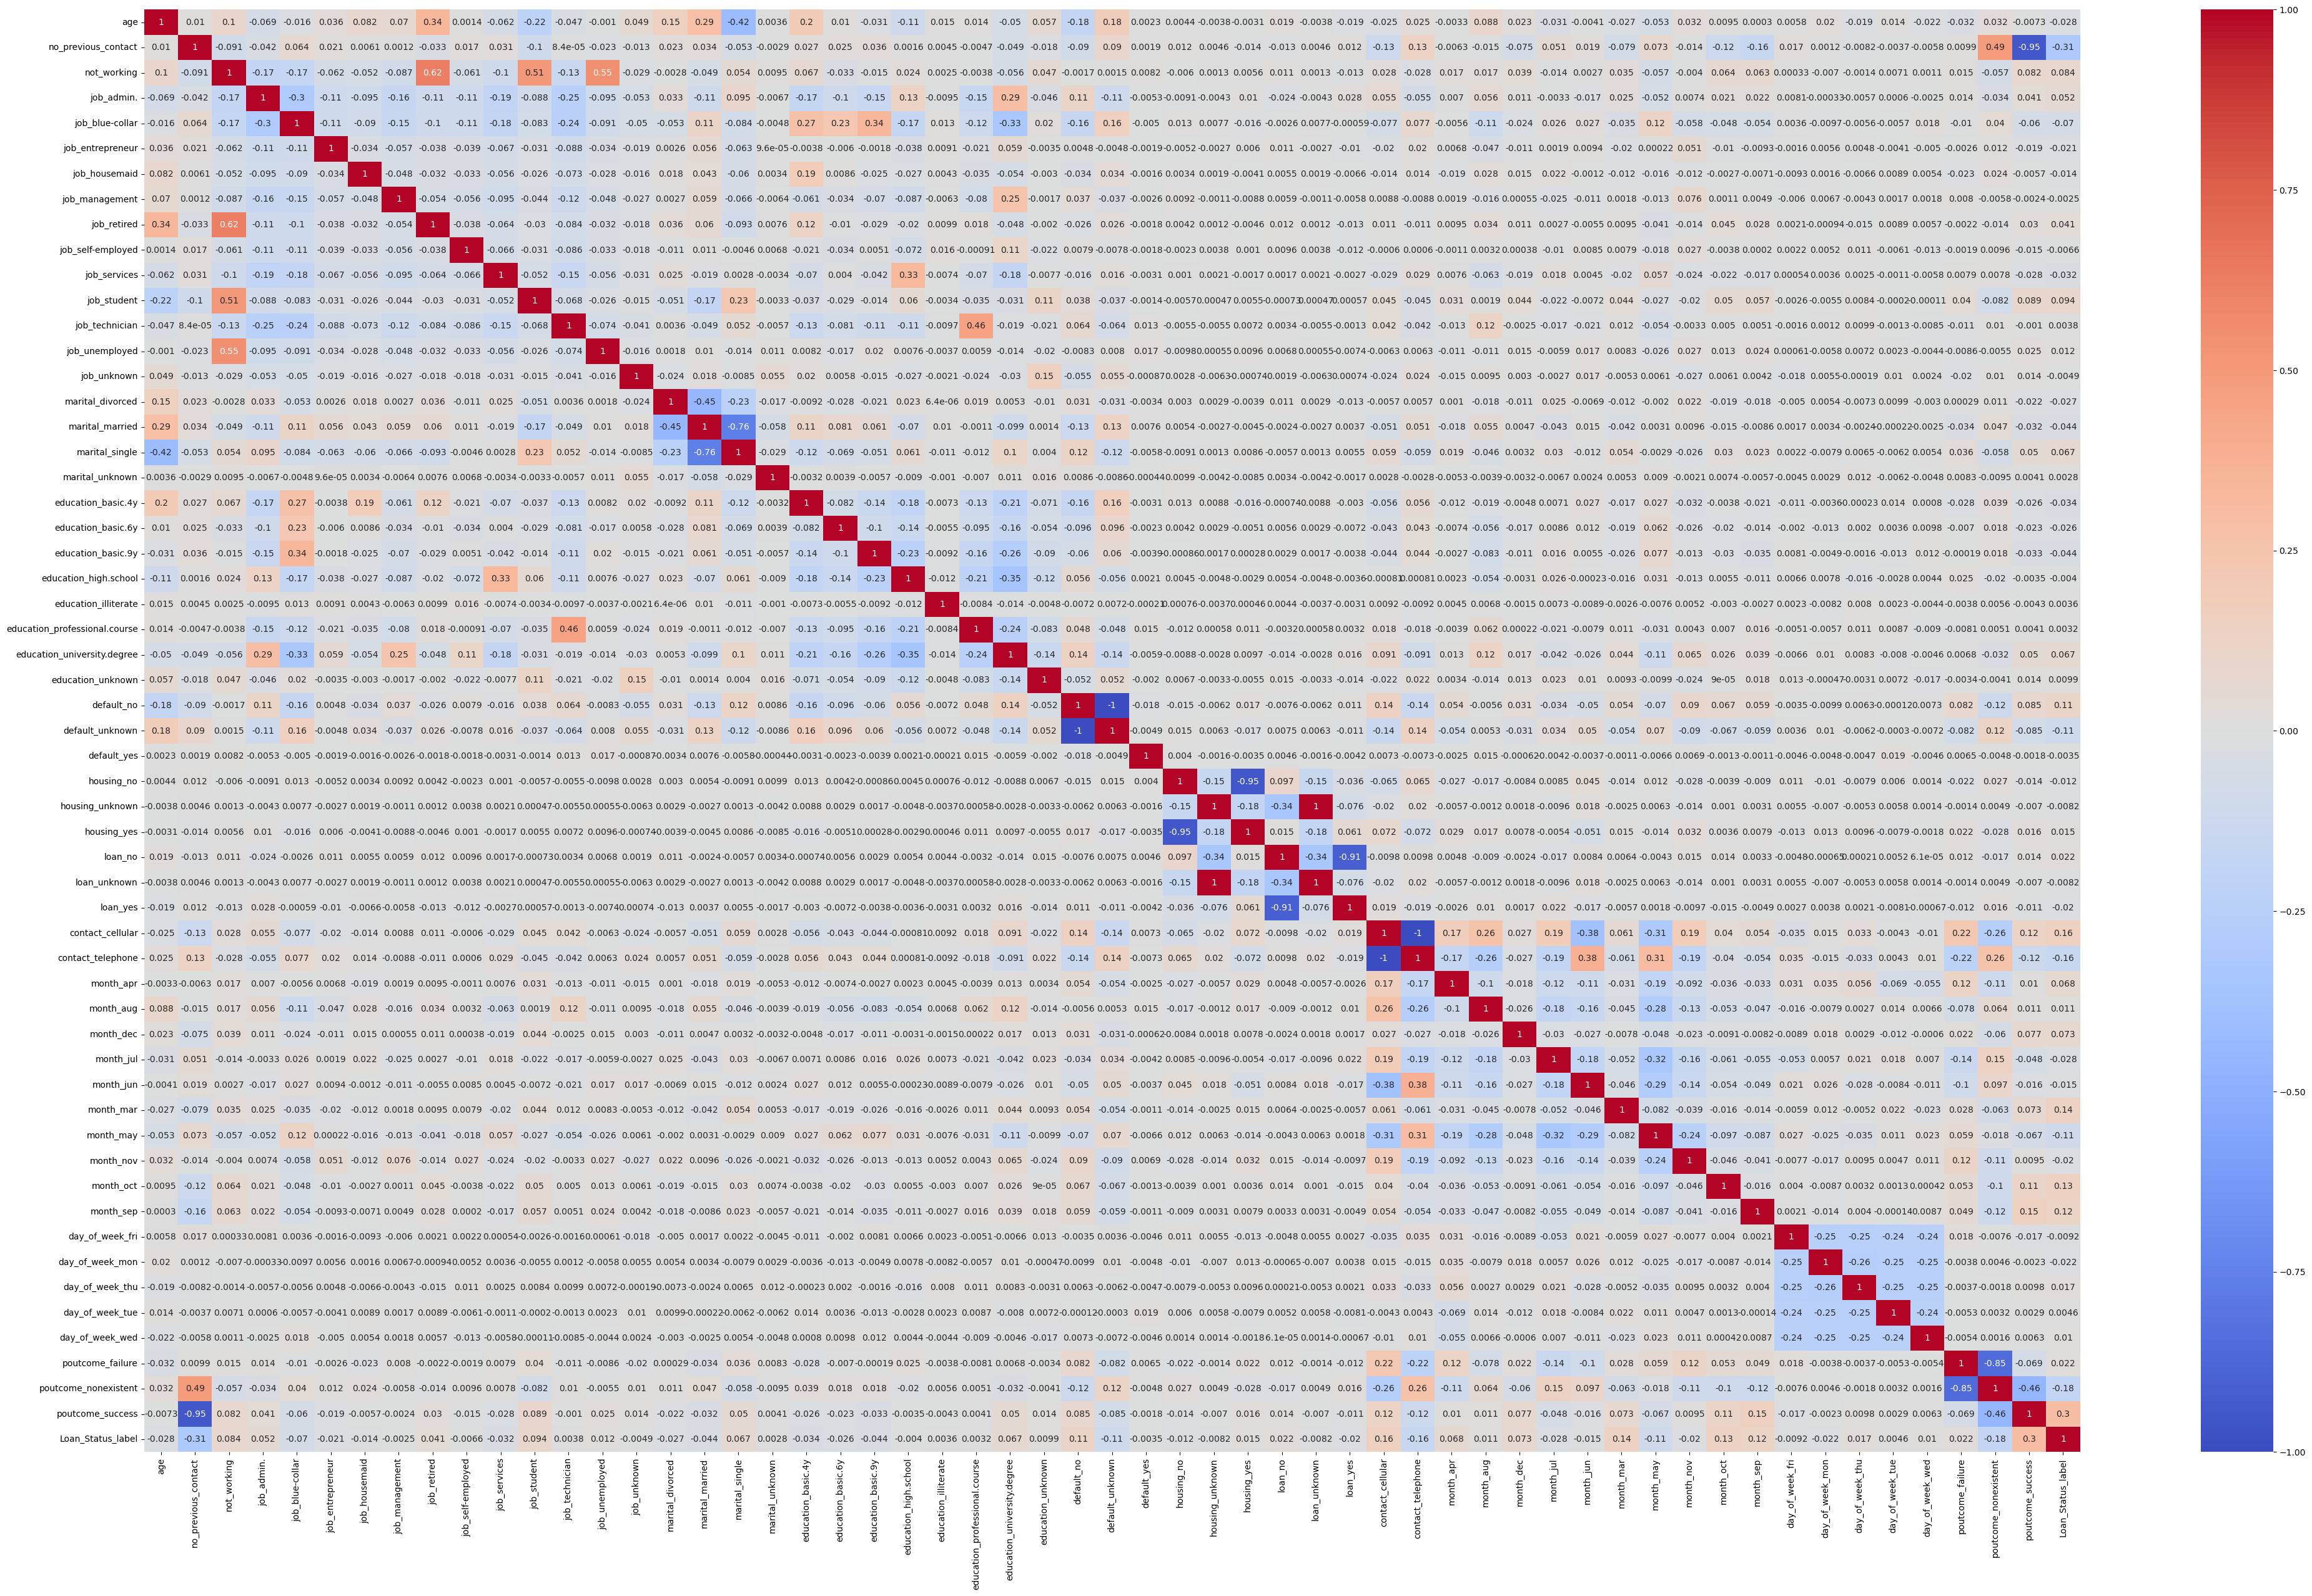

In [370]:
plt.figure(figsize = (50,30))
sns.heatmap(sample.corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [371]:
sample.drop(columns = ['no_previous_contact', 'marital_single', 'default_unknown', 'housing_no', 'loan_unknown',
                       'loan_no', 'contact_telephone','poutcome_nonexistent'], inplace = True)

In [372]:
sample.corr()['Loan_Status_label']

age                             -0.027729
not_working                      0.084025
job_admin.                       0.052206
job_blue-collar                 -0.070153
job_entrepreneur                -0.020604
job_housemaid                   -0.014049
job_management                  -0.002497
job_retired                      0.040852
job_self-employed               -0.006577
job_services                    -0.031751
job_student                      0.093526
job_technician                   0.003780
job_unemployed                   0.011542
job_unknown                     -0.004875
marital_divorced                -0.027142
marital_married                 -0.043819
marital_unknown                  0.002780
education_basic.4y              -0.034390
education_basic.6y              -0.026475
education_basic.9y              -0.043561
education_high.school           -0.003998
education_illiterate             0.003567
education_professional.course    0.003201
education_university.degree      0

## Removing irrelevant/repetitive data

In [373]:
sample.drop(columns = ['not_working','job_unknown','marital_unknown','education_illiterate','education_unknown',
                      'default_no','default_yes','housing_unknown','contact_cellular','month_apr', 'month_aug',
                       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may','month_nov', 'month_oct', 
                       'month_sep', 'day_of_week_fri','day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
                       'day_of_week_wed'], inplace = True)

## Merging columns

In [374]:
sample['basic_education'] = sample['education_basic.4y'] + sample['education_basic.6y'] + sample['education_basic.9y']
sample['degree'] = sample['education_professional.course'] + sample['education_university.degree']
sample.drop(columns = ['education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_professional.course', 
                      'education_university.degree'], inplace = True)

In [375]:
sample['Financial_Burden'] = sample['housing_yes'] + sample['loan_yes']
sample['Age_Group'] = pd.cut(sample['age'], bins=[0, 25, 40, 60, 100], labels=[0, 1, 2, 3])
sample['Prof_Maturity'] = sample['age'] * sample['degree']
sample['Age_Success_Index'] = sample['age'] * sample['poutcome_success']
def job_stability(row):
    if row['job_retired'] or row['job_management']: return 2
    if row['job_student'] or row['job_unemployed']: return 0
    return 1
sample['Job_Stability'] = sample.apply(job_stability, axis=1)
sample['Social_Stability'] = sample['degree'] + sample['marital_married']
sample.drop(columns = ['housing_yes', 'loan_yes', 'age', 'degree', 'poutcome_success', 'job_management', 'job_unemployed', 'marital_married'], inplace = True)

In [376]:
sample

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_retired,job_self-employed,job_services,job_student,job_technician,marital_divorced,education_high.school,poutcome_failure,Loan_Status_label,basic_education,Financial_Burden,Age_Group,Prof_Maturity,Age_Success_Index,Job_Stability,Social_Stability
0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,2,0,0,1,1
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,2,0,0,1,1
2,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,1,1
3,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1
4,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,2,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41171,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,1,33,0,0,2
41173,0,0,0,0,1,0,0,0,0,0,0,1,1,0,1,3,62,0,2,2
41174,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,3,62,62,2,2
41178,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,3,62,62,2,2


In [377]:
sample.columns
sample.drop_duplicates(inplace=True)

# Model Building

## Seperate dependent and independent data

In [378]:
x = sample.drop(['Loan_Status_label'], axis=1)
y = sample['Loan_Status_label']

In [379]:
x

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_retired,job_self-employed,job_services,job_student,job_technician,marital_divorced,education_high.school,poutcome_failure,basic_education,Financial_Burden,Age_Group,Prof_Maturity,Age_Success_Index,Job_Stability,Social_Stability
0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,2,0,0,1,1
1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,0,0,1,1
2,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,1,1
3,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1
4,0,0,0,0,0,0,1,0,0,0,1,0,0,1,2,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41165,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,38,0,1,1
41171,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,33,0,0,2
41173,0,0,0,0,1,0,0,0,0,0,0,1,0,1,3,62,0,2,2
41178,0,0,0,0,1,0,0,0,0,0,0,0,0,0,3,62,62,2,2


In [380]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41165    1
41171    1
41173    1
41178    1
41186    1
Name: Loan_Status_label, Length: 6059, dtype: int64

## Splitting into train and test data

In [381]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

In [382]:
x_train

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_retired,job_self-employed,job_services,job_student,job_technician,marital_divorced,education_high.school,poutcome_failure,basic_education,Financial_Burden,Age_Group,Prof_Maturity,Age_Success_Index,Job_Stability,Social_Stability
25497,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,31,31,0,1
3241,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,50,0,2,2
4677,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,59,0,2,2
29546,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,32,0,0,1
11936,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,40,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38068,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,46,0,0,2
29043,0,1,0,0,0,0,0,0,0,0,1,1,0,0,2,0,0,1,1
24550,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,45,0,2,2
14688,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,46,0,1,1


In [383]:
x_test

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_retired,job_self-employed,job_services,job_student,job_technician,marital_divorced,education_high.school,poutcome_failure,basic_education,Financial_Burden,Age_Group,Prof_Maturity,Age_Success_Index,Job_Stability,Social_Stability
27603,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,46,0,1,2
13438,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,28,0,1,1
30437,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,59,0,1,2
37485,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,36,0,0,2
36214,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,26,26,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3167,0,0,0,0,1,0,0,0,0,0,0,0,1,1,2,0,0,2,0
36720,1,0,0,0,0,0,0,0,0,0,0,0,0,1,2,53,53,1,1
30283,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,56,56,1,2
13132,0,0,0,0,0,0,0,0,1,0,0,0,0,2,1,40,0,1,2


In [384]:
y_train

25497    0
3241     0
4677     1
29546    1
11936    1
        ..
38068    0
29043    1
24550    1
14688    0
40954    1
Name: Loan_Status_label, Length: 4847, dtype: int64

In [385]:
y_test

27603    0
13438    1
30437    1
37485    0
36214    1
        ..
3167     0
36720    1
30283    1
13132    0
15642    1
Name: Loan_Status_label, Length: 1212, dtype: int64

In [386]:
#Upsampling to reduce bias
smote = SMOTE(random_state = 42, k_neighbors = 5)
x_train,y_train = smote.fit_resample(x_train, y_train)

## Model selection

### Logistic Regression

In [171]:
model1 = LogisticRegression()
model1.fit(x_train, y_train)

LogisticRegression()

In [172]:
print(f'Training Accuracy : {round(model1.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model1.score(x_test, y_test), 2)*100} %')

Training Accuracy : 66.0 %
Test Accuracy : 62.0 %


### ExtraTreesClassifier

In [387]:
model2 = model = ExtraTreesClassifier(
    n_estimators=500, 
    max_depth=7, 
    min_samples_split=2,
    criterion='entropy',
    bootstrap=True,
    random_state=100
)
model2.fit(x_train, y_train)

ExtraTreesClassifier(bootstrap=True, criterion='entropy', max_depth=7,
                     n_estimators=500, random_state=100)

In [388]:
print(f'Training Accuracy : {round(model2.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model2.score(x_test, y_test), 2)*100} %')

Training Accuracy : 68.0 %
Test Accuracy : 62.0 %


### SVM

In [180]:
model3 = SVC(kernel = 'poly', degree = 3, C = 10)
model3.fit(x_train, y_train)

SVC(C=10, kernel='poly')

In [181]:
print(f'Training Accuracy : {round(model3.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model3.score(x_test, y_test), 2)*100} %')

Training Accuracy : 63.0 %
Test Accuracy : 53.0 %


## Decision Tree

In [186]:
model4 = DecisionTreeClassifier(max_depth=7)
model4.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=7)

In [187]:
print(f'Training Accuracy : {round(model4.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model4.score(x_test, y_test), 2)*100} %')

Training Accuracy : 66.0 %
Test Accuracy : 60.0 %


## KNN

In [192]:
model5 = KNeighborsClassifier(n_neighbors=5)
model5.fit(x_train, y_train)

KNeighborsClassifier()

In [193]:
print(f'Training Accuracy : {round(model5.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model5.score(x_test, y_test), 2)*100} %')

Training Accuracy : 76.0 %
Test Accuracy : 50.0 %


### Gradient Boosting clssifier

In [202]:
model6 = GradientBoostingClassifier(n_estimators=250, learning_rate=0.5, max_depth=2, random_state=42)
model6.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.5, max_depth=2, n_estimators=250,
                           random_state=42)

In [203]:
print(f'Training Accuracy : {round(model6.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model6.score(x_test, y_test), 2)*100} %')

Training Accuracy : 71.0 %
Test Accuracy : 63.0 %


### RandomForestClassifier

In [264]:
model7 = RandomForestClassifier(n_estimators=190, max_depth=6, random_state=95)
model7.fit(x_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=190, random_state=95)

In [265]:
print(f'Training Accuracy : {round(model7.score(x_train, y_train), 2)*100} %')
print(f'Test Accuracy : {round(model7.score(x_test, y_test), 2)*100} %')

Training Accuracy : 68.0 %
Test Accuracy : 63.0 %


# Model Prediction

In [389]:
y_pred_train = model2.predict(x_train)
y_pred_test = model2.predict(x_test)

In [390]:
y_train[4000:4010]

4000    0
4001    0
4002    1
4003    0
4004    0
4005    1
4006    1
4007    1
4008    1
4009    0
Name: Loan_Status_label, dtype: int64

In [391]:
y_pred_train[4000:4010]

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

# Model Evaluation

<Axes: >

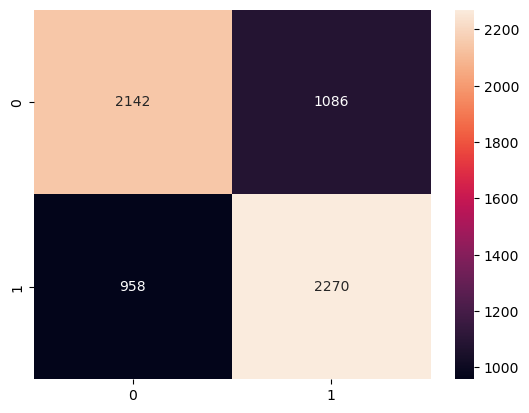

In [392]:
sns.heatmap(confusion_matrix(y_train, y_pred_train), annot=True, fmt='.4g')

In [393]:
accuracy_score(y_train, y_pred_train)

0.6833952912019826

In [394]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.69      0.66      0.68      3228
           1       0.68      0.70      0.69      3228

    accuracy                           0.68      6456
   macro avg       0.68      0.68      0.68      6456
weighted avg       0.68      0.68      0.68      6456



<Axes: >

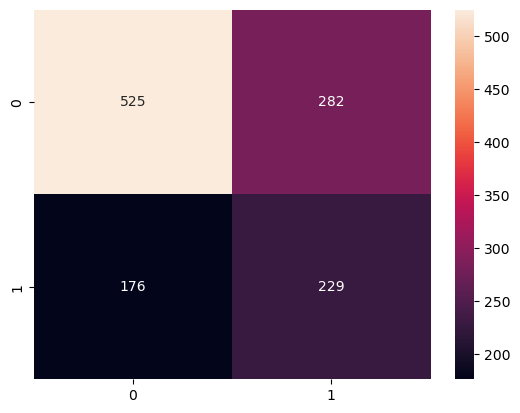

In [395]:
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='.4g')

In [396]:
accuracy_score(y_test, y_pred_test)

0.6221122112211221

In [397]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.75      0.65      0.70       807
           1       0.45      0.57      0.50       405

    accuracy                           0.62      1212
   macro avg       0.60      0.61      0.60      1212
weighted avg       0.65      0.62      0.63      1212



In [398]:
joblib.dump(model2, 'credit model.pkl')

['credit model.pkl']